#### Stochastic Simulation Project 2
Sophia Reiffenstein Petersen (s224222), Edvin Smajlovic (s224204) & Adam Bøttcher Haupt-Hansen (s224202) 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def rate1(t):
    return max(0.0, -(1/3650) * t**2 + (1/10) * t)

def rate2(t):
    return (1/5) * rate1(t)

RATE1_MAX = 9.125  # peak of rate1(t), at its vertex t = 182.5
RATE2_MAX = RATE1_MAX / 5

def lam1(t):
    # Thinning (Lewis-Shedler) algorithm: propose at the peak rate, accept/reject by the true local rate.
    # Avoids drawing absurd inter-arrival times near t=0, where rate1(t) is close to zero.
    t0 = t
    while True:
        t += np.random.exponential(1 / RATE1_MAX)
        if t >= 365 or np.random.uniform() <= rate1(t) / RATE1_MAX:
            return t - t0

def lam2(t):
    t0 = t
    while True:
        t += np.random.exponential(1 / RATE2_MAX)
        if t >= 365 or np.random.uniform() <= rate2(t) / RATE2_MAX:
            return t - t0

def lam3(t):
    return np.random.exponential(1 / 6)

In [ ]:
def los1():
    return np.random.lognormal(mean=np.log(4 * np.sqrt(2)), sigma=np.log(2))
def los2():
    return np.random.lognormal(mean=np.log(6 * np.sqrt(2)), sigma=np.log(2))
def los3():
    return np.random.lognormal(mean=np.log(5 * np.sqrt(2)), sigma=np.log(2))

In [ ]:
def simulate_hospital(arrival_rates, service_rates, ward_capacities, simulation_time):
    t = 1e-6  # Start time, avoid zero to prevent issues with arrival rate functions
    total_capacities = list(ward_capacities)
    ward_capacities = list(ward_capacities)  # local copy so the caller's list isn't mutated
    n_wards = len(ward_capacities)
    event_queue = []
    ward_arrivals = {ward: 0 for ward in range(n_wards)}
    ward_rejected = {ward: 0 for ward in range(n_wards)}
    # occupancy_history[ward] holds (time, beds_occupied) recorded on every admit/departure
    occupancy_history = {ward: [(0.0, 0)] for ward in range(n_wards)}
    # rejection_times[ward] holds the time of every rejected arrival
    rejection_times = {ward: [] for ward in range(n_wards)}

    # Initialize the event queue with the first arrival for each ward
    for ward in range(n_wards):
        event_queue.append((t + arrival_rates[ward](t), 'arrival', ward))
    # Sort the event queue by time
    event_queue.sort(key=lambda x: x[0])

    #Begin simulation loop
    while event_queue and event_queue[0][0] < simulation_time:
        # Get the next event
        t, event_type, ward = event_queue.pop(0)

        if event_type == 'arrival':
            ward_arrivals[ward] += 1
            # Check if the ward has capacity
            if ward_capacities[ward] > 0:
                # Admit the patient and schedule a departure
                ward_capacities[ward] -= 1
                occupancy_history[ward].append((t, total_capacities[ward] - ward_capacities[ward]))
                service_time = service_rates[ward]()
                event_queue.append((t + service_time, 'departure', ward))
            else:
                if ward == 1 and ward_capacities[0] > 0:
                    # Ward 1 is full, but Ward 0 has capacity, redirect the patient
                    ward_capacities[0] -= 1
                    occupancy_history[0].append((t, total_capacities[0] - ward_capacities[0]))
                    service_time = service_rates[0]()
                    event_queue.append((t + service_time, 'departure', 0))
                else:
                    # Ward is full, reject the patient
                    ward_rejected[ward] += 1
                    rejection_times[ward].append(t)

            # Schedule the next arrival for this ward
            next_arrival_time = t + arrival_rates[ward](t)
            event_queue.append((next_arrival_time, 'arrival', ward))
            event_queue.sort(key=lambda x: x[0])
        else:
            # Departure event, free up the ward capacity
            ward_capacities[ward] += 1
            occupancy_history[ward].append((t, total_capacities[ward] - ward_capacities[ward]))

    return ward_rejected, ward_arrivals, occupancy_history, rejection_times

In [ ]:
ward_capacities = [15, 10, 50]
arrival_rates = [lam1, lam2, lam3]
service_rates = [los1, los2, los3]

In [ ]:
simulation_time = 365  # Simulate for one year
ward_rejected, ward_arrivals, occupancy_history, rejection_times = simulate_hospital(arrival_rates, service_rates, ward_capacities, simulation_time)
rejection_rate = {ward: ward_rejected[ward] / ward_arrivals[ward] for ward in ward_rejected}
print("Rejection rate in each ward:", {ward: round(rate, 4) for ward, rate in rejection_rate.items()})

Rejection rate in each ward: {0: 0.6899, 1: 0.2839, 2: 0.1458}


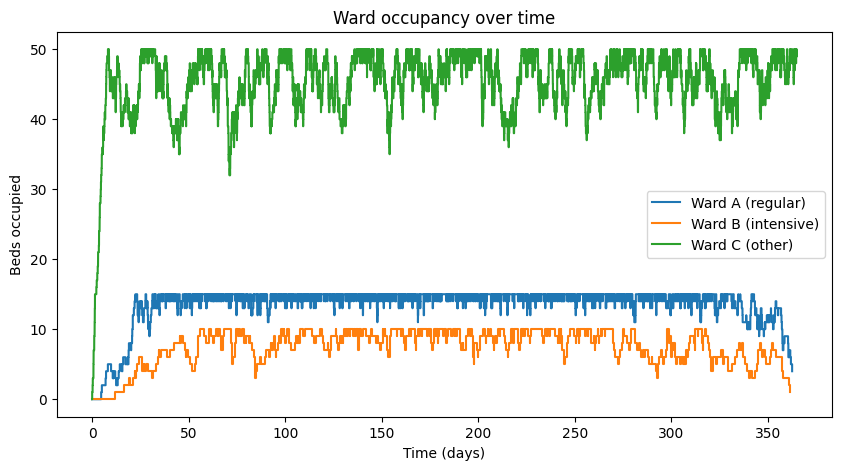

In [ ]:
ward_names = ['Ward A (regular)', 'Ward B (intensive)', 'Ward C (other)']

fig, ax = plt.subplots(figsize=(10, 5))
for ward, history in occupancy_history.items():
    times, occupied = zip(*history)
    ax.step(times, occupied, where='post', label=ward_names[ward])
ax.set_xlabel('Time (days)')
ax.set_ylabel('Beds occupied')
ax.set_title('Ward occupancy over time')
ax.legend()
plt.show()

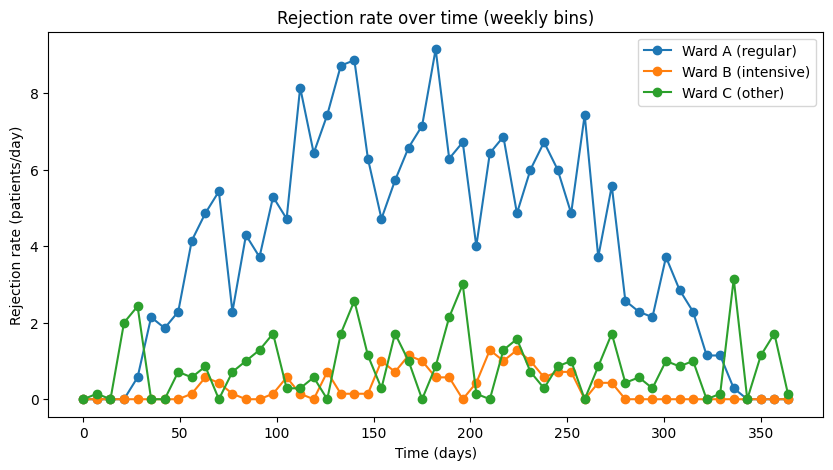

In [ ]:
bin_width = 7  # days per bin
bins = np.arange(0, simulation_time + bin_width, bin_width)

fig, ax = plt.subplots(figsize=(10, 5))
for ward, times in rejection_times.items():
    counts, _ = np.histogram(times, bins=bins)
    binned_rejection_rate = counts / bin_width  # rejected patients per day, within each bin
    ax.plot(bins[:-1], binned_rejection_rate, marker='o', label=ward_names[ward])
ax.set_xlabel('Time (days)')
ax.set_ylabel('Rejection rate (patients/day)')
ax.set_title('Rejection rate over time (weekly bins)')
ax.legend()
plt.show()

## Sensitivity: exponential LOS instead of lognormal

Same mean length-of-stay per ward (8, 12, 10 days), but exponentially distributed instead of lognormal.

In [ ]:
def los1_exp():
    return np.random.exponential(scale=8)
def los2_exp():
    return np.random.exponential(scale=12)
def los3_exp():
    return np.random.exponential(scale=10)

service_rates_exp = [los1_exp, los2_exp, los3_exp]
ward_rejected_exp, ward_arrivals_exp, occupancy_history_exp, rejection_times_exp = simulate_hospital(
    arrival_rates, service_rates_exp, ward_capacities, simulation_time
)
rejection_rate_exp = {ward: ward_rejected_exp[ward] / ward_arrivals_exp[ward] for ward in ward_rejected_exp}

print("Rejection rate in each ward (lognormal LOS):  ", {ward: round(rate, 4) for ward, rate in rejection_rate.items()})
print("Rejection rate in each ward (exponential LOS):", {ward: round(rate, 4) for ward, rate in rejection_rate_exp.items()})

Rejection rate in each ward (lognormal LOS):   {0: 0.6899, 1: 0.2839, 2: 0.1458}
Rejection rate in each ward (exponential LOS): {0: 0.7392, 1: 0.3566, 2: 0.2468}


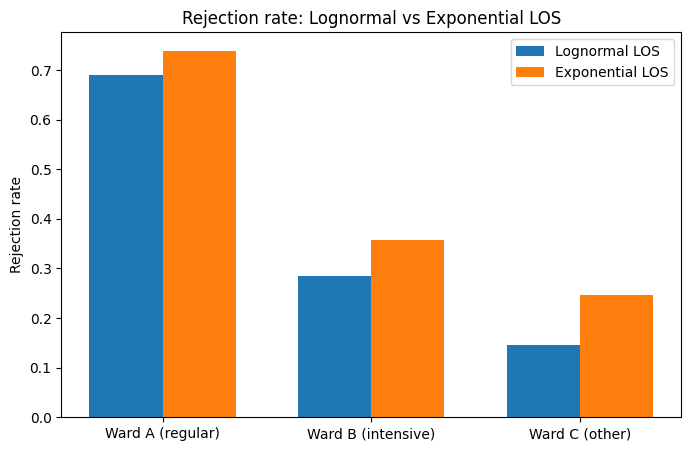

In [ ]:
n_wards = len(ward_names)
x = np.arange(n_wards)
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, [rejection_rate[w] for w in range(n_wards)], width, label='Lognormal LOS')
ax.bar(x + width/2, [rejection_rate_exp[w] for w in range(n_wards)], width, label='Exponential LOS')
ax.set_xticks(x)
ax.set_xticklabels(ward_names)
ax.set_ylabel('Rejection rate')
ax.set_title('Rejection rate: Lognormal vs Exponential LOS')
ax.legend()
plt.show()

## Statistical test: is the difference in rejections significant?

In [ ]:
from scipy import stats

n_reps = 200
rate_log = {ward: [] for ward in range(n_wards)}
rate_exp = {ward: [] for ward in range(n_wards)}

for _ in range(n_reps):
    rej_log, arr_log, _, _ = simulate_hospital(arrival_rates, service_rates, ward_capacities, simulation_time)
    rej_exp, arr_exp, _, _ = simulate_hospital(arrival_rates, service_rates_exp, ward_capacities, simulation_time)
    for ward in range(n_wards):
        rate_log[ward].append(rej_log[ward] / arr_log[ward])
        rate_exp[ward].append(rej_exp[ward] / arr_exp[ward])

# Overall rate per replication: total rejected over total arrivals, across all wards
total_rate_log = [sum(rate_log[ward][i] for ward in range(n_wards)) / n_wards for i in range(n_reps)]
total_rate_exp = [sum(rate_exp[ward][i] for ward in range(n_wards)) / n_wards for i in range(n_reps)]

In [ ]:
def report_test(name, sample_a, sample_b, label_a='A', label_b='B'):
    t_stat, p_t = stats.ttest_ind(sample_a, sample_b, equal_var=False)  # Welch's t-test
    u_stat, p_u = stats.mannwhitneyu(sample_a, sample_b, alternative='two-sided')
    print(f"{name}:")
    print(f"  {label_a}: mean={np.mean(sample_a):.4f}  std={np.std(sample_a, ddof=1):.4f}")
    print(f"  {label_b}: mean={np.mean(sample_b):.4f}  std={np.std(sample_b, ddof=1):.4f}")
    print(f"  Welch's t-test:    t={t_stat:.3f}, p={p_t:.4f}")
    print(f"  Mann-Whitney U:    U={u_stat:.1f}, p={p_u}")
    print(f"  Significant at 5%? {'yes' if p_t < 0.05 else 'no'}")
    print()

for ward in range(n_wards):
    report_test(ward_names[ward], rate_log[ward], rate_exp[ward], 'Lognormal', 'Exponential')
report_test("Average rejection rate (all wards)", total_rate_log, total_rate_exp, 'Lognormal', 'Exponential')

Ward A (regular):
  Lognormal: mean=0.7078  std=0.0107
  Exponential: mean=0.7353  std=0.0117
  Welch's t-test:    t=-24.423, p=0.0000
  Mann-Whitney U:    U=1617.5, p=6.395325916228259e-57
  Significant at 5%? yes

Ward B (intensive):
  Lognormal: mean=0.3188  std=0.0276
  Exponential: mean=0.3601  std=0.0327
  Welch's t-test:    t=-13.687, p=0.0000
  Mann-Whitney U:    U=6674.0, p=9.776089215809666e-31
  Significant at 5%? yes

Ward C (other):
  Lognormal: mean=0.1453  std=0.0171
  Exponential: mean=0.2071  std=0.0214
  Welch's t-test:    t=-31.921, p=0.0000
  Mann-Whitney U:    U=514.0, p=9.824414017954762e-64
  Significant at 5%? yes

Average rejection rate (all wards):
  Lognormal: mean=0.3906  std=0.0122
  Exponential: mean=0.4342  std=0.0140
  Welch's t-test:    t=-33.204, p=0.0000
  Mann-Whitney U:    U=415.0, p=2.3001959737234196e-64
  Significant at 5%? yes



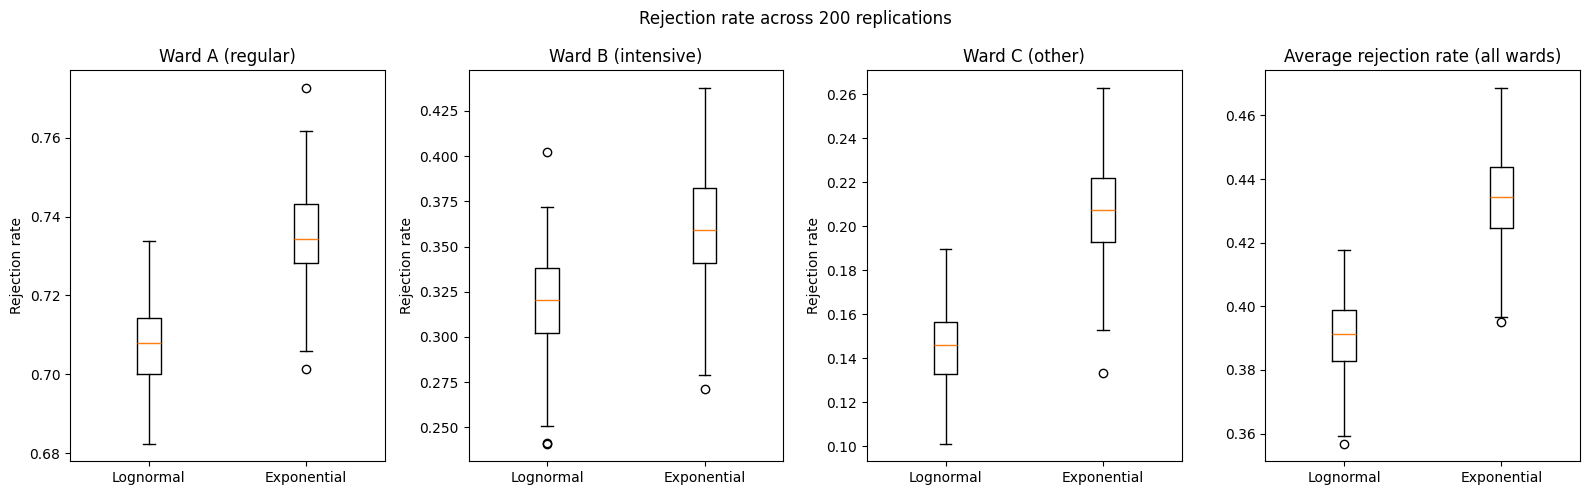

In [ ]:
fig, axes = plt.subplots(1, n_wards + 1, figsize=(4 * (n_wards + 1), 5), sharey=False)
for ward in range(n_wards):
    axes[ward].boxplot([rate_log[ward], rate_exp[ward]], tick_labels=['Lognormal', 'Exponential'])
    axes[ward].set_title(ward_names[ward])
    axes[ward].set_ylabel('Rejection rate')
axes[-1].boxplot([total_rate_log, total_rate_exp], tick_labels=['Lognormal', 'Exponential'])
axes[-1].set_title('Average rejection rate (all wards)')
fig.suptitle(f'Rejection rate across {n_reps} replications')
plt.tight_layout()
plt.show()

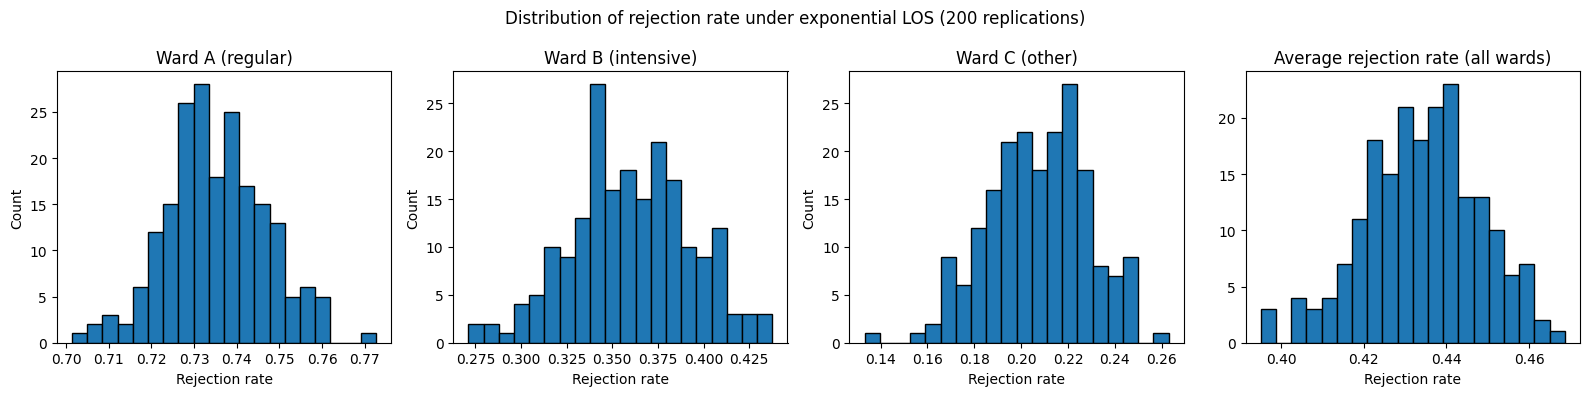

In [ ]:
fig, axes = plt.subplots(1, n_wards + 1, figsize=(4 * (n_wards + 1), 4), sharey=False)
for ward in range(n_wards):
    axes[ward].hist(rate_exp[ward], bins=20, edgecolor='black')
    axes[ward].set_title(ward_names[ward])
    axes[ward].set_xlabel('Rejection rate')
    axes[ward].set_ylabel('Count')
axes[-1].hist(total_rate_exp, bins=20, edgecolor='black')
axes[-1].set_title('Average rejection rate (all wards)')
axes[-1].set_xlabel('Rejection rate')
fig.suptitle(f'Distribution of rejection rate under exponential LOS ({n_reps} replications)')
plt.tight_layout()
plt.show()

## Sensitivity: extra beds

Same bed ratio as the baseline `[15, 10, 50]`, scaled up to 90 beds total: `[18, 12, 60]`.

In [ ]:
new_capacities = [18, 12, 60]  # same ratio as [15, 10, 50], scaled to 90 beds total

In [ ]:
ward_rejected_new, ward_arrivals_new, occupancy_history_new, rejection_times_new = simulate_hospital(
    arrival_rates, service_rates, new_capacities, simulation_time
)
rejection_rate_new = {ward: ward_rejected_new[ward] / ward_arrivals_new[ward] for ward in ward_rejected_new}

print("Rejection rate in each ward (75 beds, [15,10,50]):", {ward: round(rate, 4) for ward, rate in rejection_rate.items()})
print("Rejection rate in each ward (90 beds, [18,12,60]):", {ward: round(rate, 4) for ward, rate in rejection_rate_new.items()})

Rejection rate in each ward (75 beds, [15,10,50]): {0: 0.6899, 1: 0.2839, 2: 0.1458}
Rejection rate in each ward (90 beds, [18,12,60]): {0: 0.6643, 1: 0.2426, 2: 0.0517}


In [ ]:
rate_base = {ward: [] for ward in range(n_wards)}
rate_new = {ward: [] for ward in range(n_wards)}

for _ in range(n_reps):
    rej_base, arr_base, _, _ = simulate_hospital(arrival_rates, service_rates, ward_capacities, simulation_time)
    rej_new, arr_new, _, _ = simulate_hospital(arrival_rates, service_rates, new_capacities, simulation_time)
    for ward in range(n_wards):
        rate_base[ward].append(rej_base[ward] / arr_base[ward])
        rate_new[ward].append(rej_new[ward] / arr_new[ward])

total_rate_base = [sum(rate_base[ward][i] for ward in range(n_wards)) / n_wards for i in range(n_reps)]
total_rate_new = [sum(rate_new[ward][i] for ward in range(n_wards)) / n_wards for i in range(n_reps)]

for ward in range(n_wards):
    report_test(ward_names[ward], rate_base[ward], rate_new[ward], '75 beds', '90 beds')
report_test("Average rejection rate (all wards)", total_rate_base, total_rate_new, '75 beds', '90 beds')

Ward A (regular):
  75 beds: mean=0.7087  std=0.0110
  90 beds: mean=0.6483  std=0.0108
  Welch's t-test:    t=55.426, p=0.0000
  Mann-Whitney U:    U=40000.0, p=4.830448488384059e-67
  Significant at 5%? yes

Ward B (intensive):
  75 beds: mean=0.3172  std=0.0265
  90 beds: mean=0.2374  std=0.0269
  Welch's t-test:    t=29.861, p=0.0000
  Mann-Whitney U:    U=39208.0, p=5.570077397537998e-62
  Significant at 5%? yes

Ward C (other):
  75 beds: mean=0.1416  std=0.0174
  90 beds: mean=0.0435  std=0.0120
  Welch's t-test:    t=65.597, p=0.0000
  Mann-Whitney U:    U=40000.0, p=4.830652435142516e-67
  Significant at 5%? yes

Average rejection rate (all wards):
  75 beds: mean=0.3892  std=0.0115
  90 beds: mean=0.3097  std=0.0109
  Welch's t-test:    t=70.766, p=0.0000
  Mann-Whitney U:    U=40000.0, p=4.830856390397399e-67
  Significant at 5%? yes



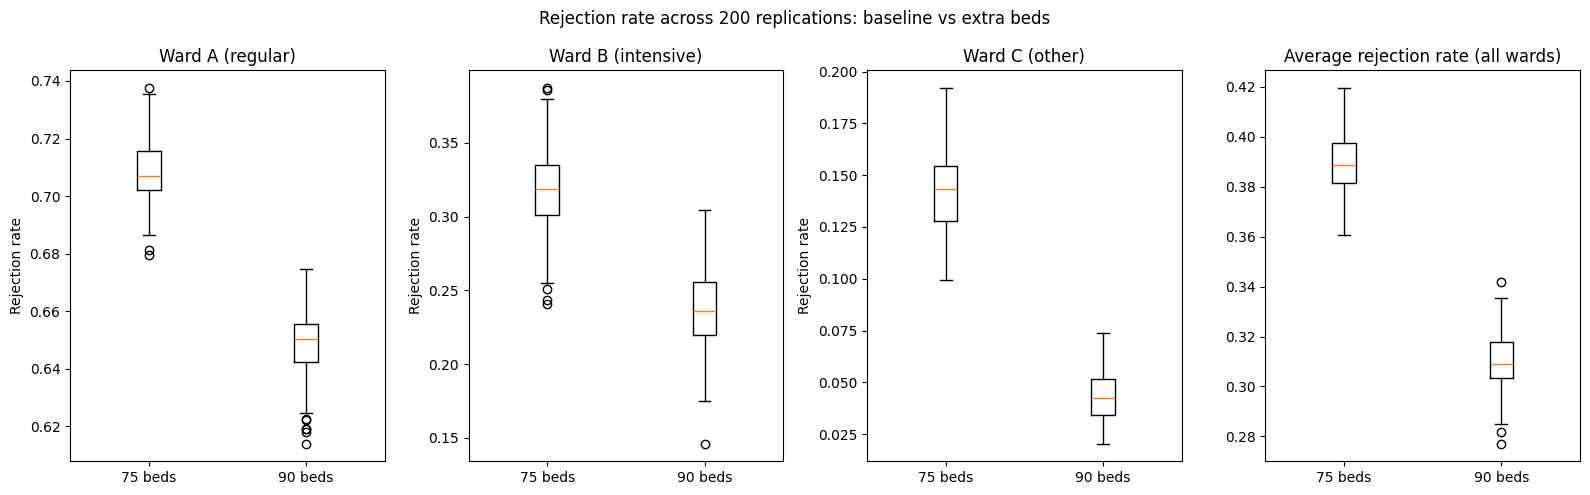

In [ ]:
fig, axes = plt.subplots(1, n_wards + 1, figsize=(4 * (n_wards + 1), 5), sharey=False)
for ward in range(n_wards):
    axes[ward].boxplot([rate_base[ward], rate_new[ward]], tick_labels=['75 beds', '90 beds'])
    axes[ward].set_title(ward_names[ward])
    axes[ward].set_ylabel('Rejection rate')
axes[-1].boxplot([total_rate_base, total_rate_new], tick_labels=['75 beds', '90 beds'])
axes[-1].set_title('Average rejection rate (all wards)')
fig.suptitle(f'Rejection rate across {n_reps} replications: baseline vs extra beds')
plt.tight_layout()
plt.show()

## Sensitivity: rejection rate vs total number of beds

Sweep the total bed count, keeping the same ward ratio as the baseline `[15, 10, 50]`, and track how the overall rejection rate changes.

In [ ]:
bed_ratio = np.array(ward_capacities) / sum(ward_capacities)
total_beds_range = np.arange(30, 151, 10)
n_reps_sweep = 30

sweep_mean = []
sweep_se = []

for total_beds in total_beds_range:
    capacities = np.round(bed_ratio * total_beds).astype(int)
    reps = []
    for _ in range(n_reps_sweep):
        rej, arr, _, _ = simulate_hospital(arrival_rates, service_rates, capacities, simulation_time)
        overall_rate = np.mean([rej[ward] / arr[ward] for ward in range(n_wards)])
        reps.append(overall_rate)
    sweep_mean.append(np.mean(reps))
    sweep_se.append(np.std(reps, ddof=1) / np.sqrt(n_reps_sweep))

sweep_mean = np.array(sweep_mean)
sweep_se = np.array(sweep_se)

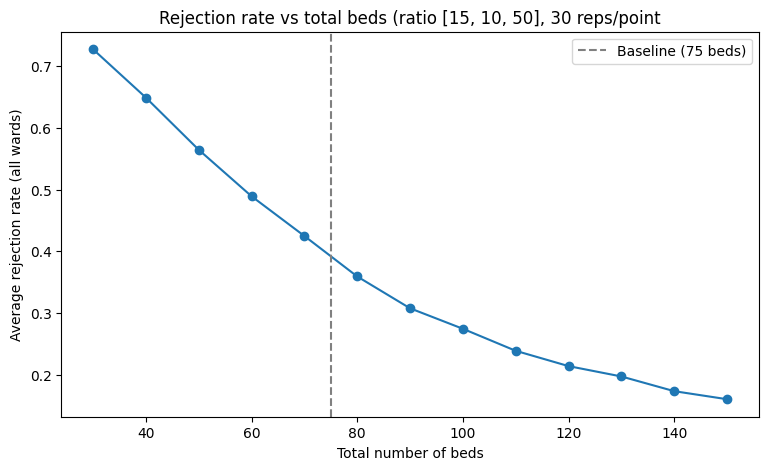

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(total_beds_range, sweep_mean, marker='o')
#ax.fill_between(total_beds_range, sweep_mean - 1.96 * sweep_se, sweep_mean + 1.96 * sweep_se, alpha=0.2)
ax.axvline(sum(ward_capacities), color='gray', linestyle='--', label=f'Baseline ({sum(ward_capacities)} beds)')
ax.set_xlabel('Total number of beds')
ax.set_ylabel('Average rejection rate (all wards)')
ax.set_title(f'Rejection rate vs total beds (ratio {list(ward_capacities)}, {n_reps_sweep} reps/point')
ax.legend()
plt.show()

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.stats as stats
import random
from functions_project2 import *

#### Primary Task

In [38]:
np.random.seed(42)
total_beds = 75
Ward_A_LOS = lambda: np.random.lognormal(mean=np.log(4*np.sqrt(2)), sigma=np.sqrt(np.log(2)))
Ward_B_LOS = lambda: np.random.lognormal(mean=np.log(6*np.sqrt(2)), sigma=np.sqrt(np.log(2)))
Ward_C_LOS = lambda: np.random.lognormal(mean=np.log(5*np.sqrt(2)), sigma=np.sqrt(np.log(2)))

runs = 1000
blocking_probabilities_A = []
blocking_probabilities_B = []
blocking_probabilities_C = []

for _ in range(runs):
    results = simulate_patient_flow((20, 10), simulation_days=365, Ward_A_LOS=Ward_A_LOS, Ward_B_LOS=Ward_B_LOS, Ward_C_LOS=Ward_C_LOS, total_beds=total_beds)
    blocking_probabilities_A.append(results["blocking_probability"]["A"])
    blocking_probabilities_B.append(results["blocking_probability"]["B"])
    blocking_probabilities_C.append(results["blocking_probability"]["C"])

mean_A = np.mean(blocking_probabilities_A)
mean_B = np.mean(blocking_probabilities_B)
mean_C = np.mean(blocking_probabilities_C)

ci_A = conf_interval(blocking_probabilities_A)
ci_B = conf_interval(blocking_probabilities_B)
ci_C = conf_interval(blocking_probabilities_C)

print(f"Mean blocking probability for Ward A: {mean_A:.4f}, 95% CI: {ci_A}")
print(f"Mean blocking probability for Ward B: {mean_B:.4f}, 95% CI: {ci_B}")
print(f"Mean blocking probability for Ward C: {mean_C:.4f}, 95% CI: {ci_C}")

sum_relocated_A = []
sum_relocated_B = []
sum_relocated_C = []

for _ in range(runs):
    results = simulate_patient_flow((20, 10), simulation_days=365, Ward_A_LOS=Ward_A_LOS, Ward_B_LOS=Ward_B_LOS, Ward_C_LOS=Ward_C_LOS, total_beds=total_beds)
    sum_relocated_A.append(results["rejected"]["A"])
    sum_relocated_B.append(results["rejected"]["B"])
    sum_relocated_C.append(results["rejected"]["C"])

print(f"Mean number of patients rejected for Ward A: {np.mean(sum_relocated_A):.4f}")
print(f"Mean number of patients rejected for Ward B: {np.mean(sum_relocated_B):.4f}")
print(f"Mean number of patients rejected for Ward C: {np.mean(sum_relocated_C):.4f}")

print(f"Total mean number of patients rejected: {np.mean(sum_relocated_A) + np.mean(sum_relocated_B) + np.mean(sum_relocated_C):.4f}")

print(f"Percentage of patients rejected for Ward A: {np.mean(sum_relocated_A) / (np.mean(sum_relocated_A) + np.mean(sum_relocated_B) + np.mean(sum_relocated_C)) * 100:.2f}%")
print(f"Percentage of patients rejected for Ward B: {np.mean(sum_relocated_B) / (np.mean(sum_relocated_A) + np.mean(sum_relocated_B) + np.mean(sum_relocated_C)) * 100:.2f}%")
print(f"Percentage of patients rejected for Ward C: {np.mean(sum_relocated_C) / (np.mean(sum_relocated_A) + np.mean(sum_relocated_B) + np.mean(sum_relocated_C)) * 100:.2f}%")

Mean blocking probability for Ward A: 0.6460, 95% CI: (np.float64(0.6451785906907997), np.float64(0.646754683754663))
Mean blocking probability for Ward B: 0.4463, 95% CI: (np.float64(0.44416703761161636), np.float64(0.4484324635525043))
Mean blocking probability for Ward C: 0.2916, 95% CI: (np.float64(0.2902785534873555), np.float64(0.29282168244909806))
Mean number of patients rejected for Ward A: 1434.8340
Mean number of patients rejected for Ward B: 198.4710
Mean number of patients rejected for Ward C: 643.7230
Total mean number of patients rejected: 2277.0280
Percentage of patients rejected for Ward A: 63.01%
Percentage of patients rejected for Ward B: 8.72%
Percentage of patients rejected for Ward C: 28.27%


In [39]:
# Furthermore, estimate the mean fraction of beds that are utilized (occupied) in each ward.
# number of occupied bed / number of available beds in each ward. The number of available beds in each ward is given by the initial number of beds in each ward (20 for Ward A, 10 for Ward B, and 10 for Ward C) minus the number of patients that are rejected (relocated) from each ward.

Ward_A_utilization = []
Ward_B_utilization = []
Ward_C_utilization = []

for _ in range(runs):
    results = simulate_patient_flow((20, 10), simulation_days=365, Ward_A_LOS=Ward_A_LOS, Ward_B_LOS=Ward_B_LOS, Ward_C_LOS=Ward_C_LOS, total_beds=total_beds)
    Ward_A_utilization.append(results["Utilisation"]["A"])
    Ward_B_utilization.append(results["Utilisation"]["B"])
    Ward_C_utilization.append(results["Utilisation"]["C"])

print(f"Mean bed utilisation for Ward A: {np.mean(Ward_A_utilization):.4f}")
print(f"Mean bed utilisation for Ward B: {np.mean(Ward_B_utilization):.4f}")
print(f"Mean bed utilisation for Ward C: {np.mean(Ward_C_utilization):.4f}")

Mean bed utilisation for Ward A: 0.9165
Mean bed utilisation for Ward B: 0.8125
Mean bed utilisation for Ward C: 0.9653


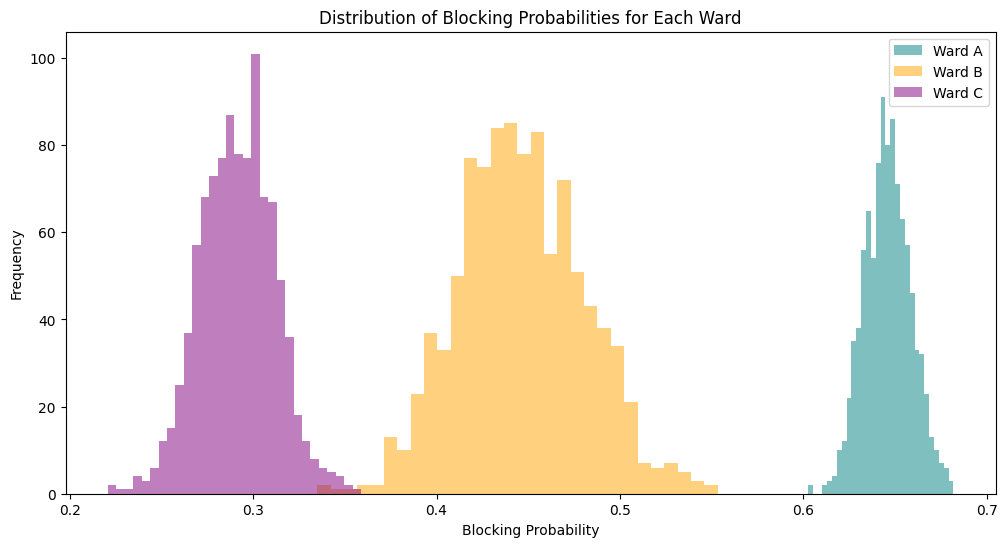

In [40]:
# visualize the distribution of blocking probabilities for each ward
plt.figure(figsize=(12, 6))
plt.hist(blocking_probabilities_A, bins=30, alpha=0.5, label='Ward A', color='teal')
plt.hist(blocking_probabilities_B, bins=30, alpha=0.5, label='Ward B', color='orange')
plt.hist(blocking_probabilities_C, bins=30, alpha=0.5, label='Ward C', color='purple')
plt.title('Distribution of Blocking Probabilities for Each Ward')
plt.xlabel('Blocking Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

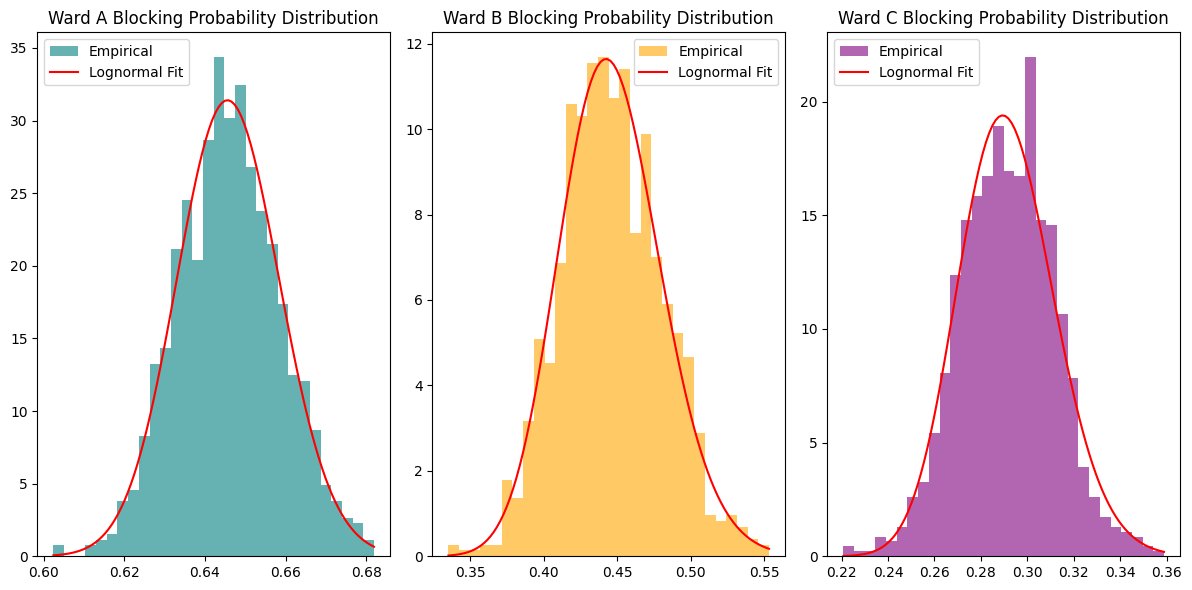

In [41]:
# Visualise Estimate the distribution of the blocking probabilities for each ward
# and compare to lognormal distribution 

probabilities = ['Ward A', 'Ward B', 'Ward C']

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.hist(blocking_probabilities_A, bins=30, density=True, alpha=0.6, color='teal', label='Empirical')
x = np.linspace(min(blocking_probabilities_A), max(blocking_probabilities_A), 100)
shape_A, loc_A, scale_A = stats.lognorm.fit(blocking_probabilities_A, floc=0)
pdf_A = stats.lognorm.pdf(x, shape_A, loc_A, scale_A)   
plt.plot(x, pdf_A, 'r-', label='Lognormal Fit')
plt.legend()
plt.title('Ward A Blocking Probability Distribution')

plt.subplot(1, 3, 2)
plt.hist(blocking_probabilities_B, bins=30, density=True, alpha=0.6, color='orange', label='Empirical')
x = np.linspace(min(blocking_probabilities_B), max(blocking_probabilities_B), 100)
shape_B, loc_B, scale_B = stats.lognorm.fit(blocking_probabilities_B, floc=0)
pdf_B = stats.lognorm.pdf(x, shape_B, loc_B, scale_B)
plt.plot(x, pdf_B, 'r-', label='Lognormal Fit')
plt.legend()
plt.title('Ward B Blocking Probability Distribution')

plt.subplot(1, 3, 3)
plt.hist(blocking_probabilities_C, bins=30, density=True, alpha=0.6, color='purple', label='Empirical')
x = np.linspace(min(blocking_probabilities_C), max(blocking_probabilities_C), 100)
shape_C, loc_C, scale_C = stats.lognorm.fit(blocking_probabilities_C, floc=0)
pdf_C = stats.lognorm.pdf(x, shape_C, loc_C, scale_C)
plt.plot(x, pdf_C, 'r-', label='Lognormal Fit')
plt.title('Ward C Blocking Probability Distribution')

plt.tight_layout()
plt.legend()
plt.show()

In [42]:
# ks test for goodness of fit
ks_stat_A, p_value_A = stats.kstest(blocking_probabilities_A, 'lognorm', args=(shape_A, loc_A, scale_A))
ks_stat_B, p_value_B = stats.kstest(blocking_probabilities_B, 'lognorm', args=(shape_B, loc_B, scale_B))
ks_stat_C, p_value_C = stats.kstest(blocking_probabilities_C, 'lognorm', args=(shape_C, loc_C, scale_C))

print(f"Ward A: KS Statistic = {ks_stat_A:.4f}, p-value = {p_value_A:.4f}")
print(f"Ward B: KS Statistic = {ks_stat_B:.4f}, p-value = {p_value_B:.4f}")
print(f"Ward C: KS Statistic = {ks_stat_C:.4f}, p-value = {p_value_C:.4f}")

Ward A: KS Statistic = 0.0155, p-value = 0.9672
Ward B: KS Statistic = 0.0195, p-value = 0.8319
Ward C: KS Statistic = 0.0338, p-value = 0.1978


#### Sensitivity Analysis

In [46]:
best_distribution, mean_rejections, results = \
    find_optimal_bed_distribution(
        total_beds=75,
        Ward_A_LOS=Ward_A_LOS,
        Ward_B_LOS=Ward_B_LOS,
        Ward_C_LOS=Ward_C_LOS,
        stage1_replications=5,
        stage2_replications=100,
        top_k=10
    )

print("\nBest distribution:")
print(best_distribution)

print("\nExpected rejections:")
print(mean_rejections)

print("\nDetailed results for the best distribution:")
print(results)

Finding optimal bed distribution...
Stage 1: Screening candidate allocations

Best distribution:
(15, 3, 57)

Expected rejections:
2263.52

Detailed results for the best distribution:
[{'beds_A': 15, 'beds_B': 3, 'beds_C': 57, 'mean_rejections': np.float64(2263.52), 'std_rejections': np.float64(79.09775054585397), 'mean_overflows': np.float64(9.97), 'mean_util_A': np.float64(0.937897716894977), 'mean_util_B': np.float64(0.9016803652968036), 'mean_util_C': np.float64(0.928510454217736)}, {'beds_A': 15, 'beds_B': 6, 'beds_C': 54, 'mean_rejections': np.float64(2271.76), 'std_rejections': np.float64(76.37283879135634), 'mean_overflows': np.float64(5.37), 'mean_util_A': np.float64(0.9345698630136985), 'mean_util_B': np.float64(0.8639132420091324), 'mean_util_C': np.float64(0.9406047691527142)}, {'beds_A': 15, 'beds_B': 5, 'beds_C': 55, 'mean_rejections': np.float64(2273.18), 'std_rejections': np.float64(70.98376254788518), 'mean_overflows': np.float64(7.28), 'mean_util_A': np.float64(0.9362

In [47]:
np.random.seed(42)

blocking_probabilities_A = []
blocking_probabilities_B = []
blocking_probabilities_C = []

for _ in range(runs):
    results = simulate_patient_flow((15, 3), simulation_days=365, Ward_A_LOS=Ward_A_LOS, Ward_B_LOS=Ward_B_LOS, Ward_C_LOS=Ward_C_LOS, total_beds=total_beds)
    blocking_probabilities_A.append(results["blocking_probability"]["A"])
    blocking_probabilities_B.append(results["blocking_probability"]["B"])
    blocking_probabilities_C.append(results["blocking_probability"]["C"])

mean_A = np.mean(blocking_probabilities_A)
mean_B = np.mean(blocking_probabilities_B)
mean_C = np.mean(blocking_probabilities_C)

ci_A = conf_interval(blocking_probabilities_A)
ci_B = conf_interval(blocking_probabilities_B)
ci_C = conf_interval(blocking_probabilities_C)

print(f"Mean blocking probability for Ward A: {mean_A:.4f}, 95% CI: {ci_A}")
print(f"Mean blocking probability for Ward B: {mean_B:.4f}, 95% CI: {ci_B}")
print(f"Mean blocking probability for Ward C: {mean_C:.4f}, 95% CI: {ci_C}")

sum_relocated_A = []
sum_relocated_B = []
sum_relocated_C = []

for _ in range(runs):
    results = simulate_patient_flow((15, 3), simulation_days=365, Ward_A_LOS=Ward_A_LOS, Ward_B_LOS=Ward_B_LOS, Ward_C_LOS=Ward_C_LOS, total_beds=total_beds)
    sum_relocated_A.append(results["rejected"]["A"])
    sum_relocated_B.append(results["rejected"]["B"])
    sum_relocated_C.append(results["rejected"]["C"])

print(f"Mean number of patients rejected for Ward A: {np.mean(sum_relocated_A):.4f}")
print(f"Mean number of patients rejected for Ward B: {np.mean(sum_relocated_B):.4f}")
print(f"Mean number of patients rejected for Ward C: {np.mean(sum_relocated_C):.4f}")

print(f"Total mean number of patients rejected: {np.mean(sum_relocated_A) + np.mean(sum_relocated_B) + np.mean(sum_relocated_C):.4f}")

print(f"Percentage of patients rejected for Ward A: {np.mean(sum_relocated_A) / (np.mean(sum_relocated_A) + np.mean(sum_relocated_B) + np.mean(sum_relocated_C)) * 100:.2f}%")
print(f"Percentage of patients rejected for Ward B: {np.mean(sum_relocated_B) / (np.mean(sum_relocated_A) + np.mean(sum_relocated_B) + np.mean(sum_relocated_C)) * 100:.2f}%")
print(f"Percentage of patients rejected for Ward C: {np.mean(sum_relocated_C) / (np.mean(sum_relocated_A) + np.mean(sum_relocated_B) + np.mean(sum_relocated_C)) * 100:.2f}%")

Mean blocking probability for Ward A: 0.7317, 95% CI: (np.float64(0.7310043309200591), np.float64(0.73243029197701))
Mean blocking probability for Ward B: 0.7952, 95% CI: (np.float64(0.7940243422070095), np.float64(0.7964701986525924))
Mean blocking probability for Ward C: 0.1348, 95% CI: (np.float64(0.13354548923337256), np.float64(0.13597846253466106))
Mean number of patients rejected for Ward A: 1626.6340
Mean number of patients rejected for Ward B: 353.1660
Mean number of patients rejected for Ward C: 299.1810
Total mean number of patients rejected: 2278.9810
Percentage of patients rejected for Ward A: 71.38%
Percentage of patients rejected for Ward B: 15.50%
Percentage of patients rejected for Ward C: 13.13%


In [48]:
# Furthermore, estimate the mean fraction of beds that are utilized (occupied) in each ward.
# number of occupied bed / number of available beds in each ward. The number of available beds in each ward is given by the initial number of beds in each ward (20 for Ward A, 10 for Ward B, and 10 for Ward C) minus the number of patients that are rejected (relocated) from each ward.

Ward_A_utilization = []
Ward_B_utilization = []
Ward_C_utilization = []

for _ in range(runs):
    results = simulate_patient_flow((15, 3), simulation_days=365, Ward_A_LOS=Ward_A_LOS, Ward_B_LOS=Ward_B_LOS, Ward_C_LOS=Ward_C_LOS, total_beds=total_beds)
    Ward_A_utilization.append(results["Utilisation"]["A"])
    Ward_B_utilization.append(results["Utilisation"]["B"])
    Ward_C_utilization.append(results["Utilisation"]["C"])

print(f"Mean bed utilisation for Ward A: {np.mean(Ward_A_utilization):.4f}")
print(f"Mean bed utilisation for Ward B: {np.mean(Ward_B_utilization):.4f}")
print(f"Mean bed utilisation for Ward C: {np.mean(Ward_C_utilization):.4f}")

Mean bed utilisation for Ward A: 0.9381
Mean bed utilisation for Ward B: 0.9003
Mean bed utilisation for Ward C: 0.9307


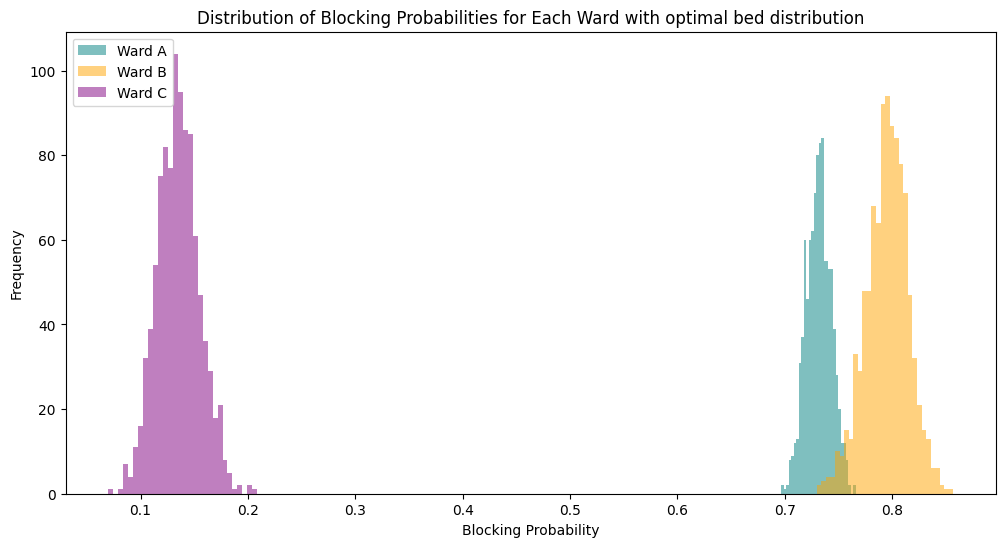

In [49]:
# visualize the distribution of blocking probabilities for each ward
plt.figure(figsize=(12, 6))
plt.hist(blocking_probabilities_A, bins=30, alpha=0.5, label='Ward A', color='teal')
plt.hist(blocking_probabilities_B, bins=30, alpha=0.5, label='Ward B', color='orange')
plt.hist(blocking_probabilities_C, bins=30, alpha=0.5, label='Ward C', color='purple')
plt.title('Distribution of Blocking Probabilities for Each Ward with optimal bed distribution')
plt.xlabel('Blocking Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [50]:
exp_blocking_probabilities_A = []
exp_blocking_probabilities_B = []
exp_blocking_probabilities_C = []

for _ in range(runs):
    exponential_LOS_results = simulate_patient_flow((20, 10), simulation_days=365, 
    Ward_A_LOS=lambda: np.random.exponential(scale=4), 
    Ward_B_LOS=lambda: np.random.exponential(scale=6), 
    Ward_C_LOS=lambda: np.random.exponential(scale=5), total_beds=total_beds)

    exp_blocking_probabilities_A.append(exponential_LOS_results["blocking_probability"]["A"])
    exp_blocking_probabilities_B.append(exponential_LOS_results["blocking_probability"]["B"])
    exp_blocking_probabilities_C.append(exponential_LOS_results["blocking_probability"]["C"])

mean_exp_A = np.mean(exp_blocking_probabilities_A)
mean_exp_B = np.mean(exp_blocking_probabilities_B)
mean_exp_C = np.mean(exp_blocking_probabilities_C)

ci_exp_A = conf_interval(exp_blocking_probabilities_A)
ci_exp_B = conf_interval(exp_blocking_probabilities_B)
ci_exp_C = conf_interval(exp_blocking_probabilities_C)

print(f"Mean blocking probability for Ward A (Exponential LOS): {mean_exp_A:.4f}, 95% CI: {ci_exp_A}")
print(f"Mean blocking probability for Ward B (Exponential LOS): {mean_exp_B:.4f}, 95% CI: {ci_exp_B}")
print(f"Mean blocking probability for Ward C (Exponential LOS): {mean_exp_C:.4f}, 95% CI: {ci_exp_C}")

Mean blocking probability for Ward A (Exponential LOS): 0.3908, 95% CI: (np.float64(0.38981729255022823), np.float64(0.3917960652767435))
Mean blocking probability for Ward B (Exponential LOS): 0.1573, 95% CI: (np.float64(0.15539700221515867), np.float64(0.1591598810993421))
Mean blocking probability for Ward C (Exponential LOS): 0.0048, 95% CI: (np.float64(0.004620021237534523), np.float64(0.005055765977623856))


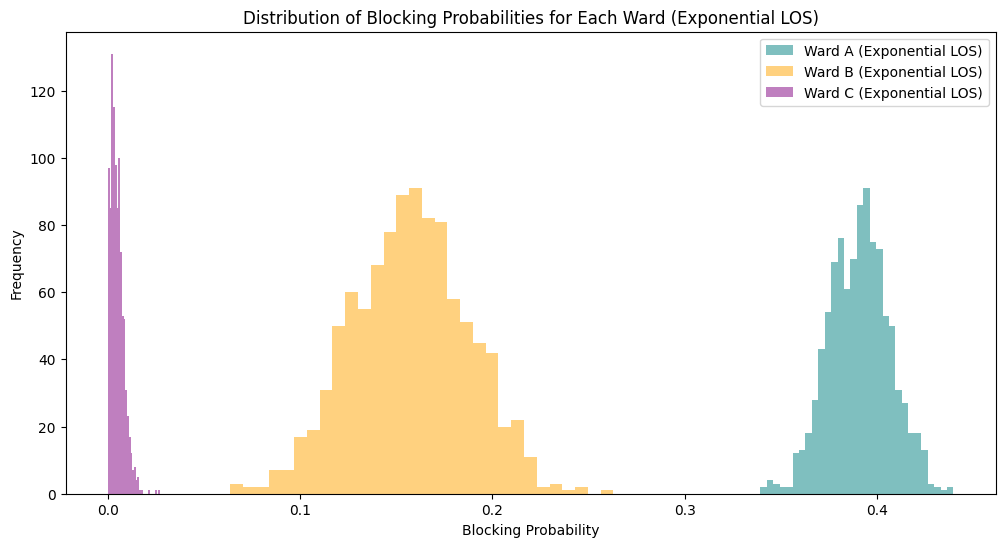

In [51]:
# visualize the results for exponential LOS

plt.figure(figsize=(12, 6))
plt.hist(exp_blocking_probabilities_A, bins=30, alpha=0.5, label='Ward A (Exponential LOS)', color='teal')
plt.hist(exp_blocking_probabilities_B, bins=30, alpha=0.5, label='Ward B (Exponential LOS)', color='orange')
plt.hist(exp_blocking_probabilities_C, bins=30, alpha=0.5, label='Ward C (Exponential LOS)', color='purple')
plt.title('Distribution of Blocking Probabilities for Each Ward (Exponential LOS)')
plt.xlabel('Blocking Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Ward A (Mean LOS = 4): KS Statistic = 0.3135, p-value = 0.0000
Ward B (Mean LOS = 6): KS Statistic = 0.3196, p-value = 0.0000
Ward C (Mean LOS = 5): KS Statistic = 0.3152, p-value = 0.0000


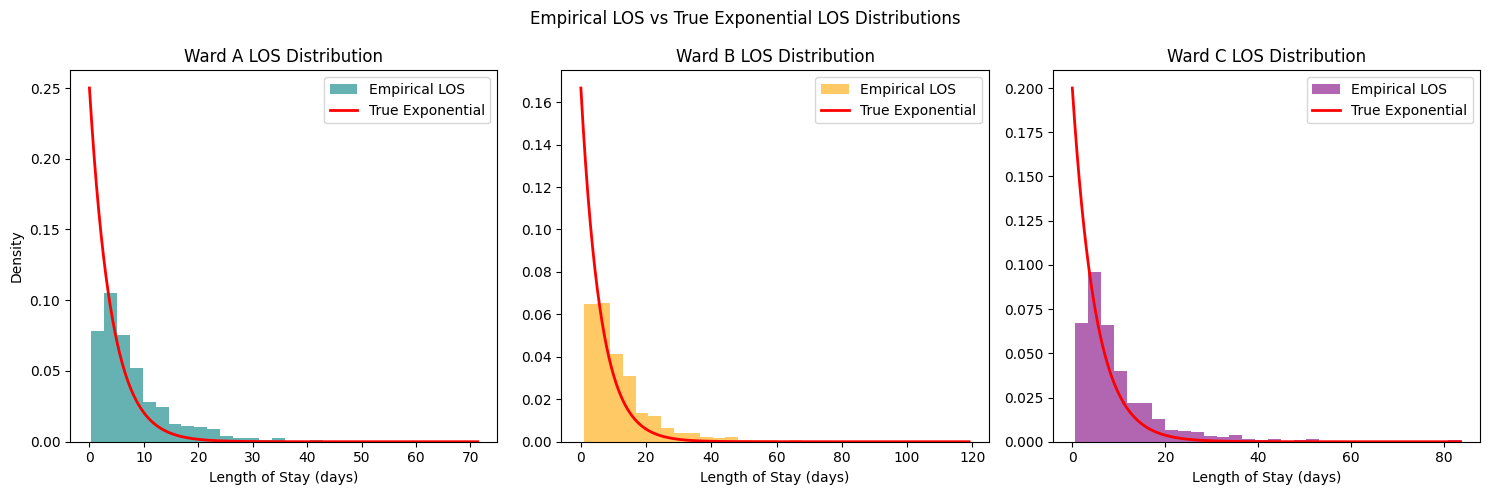

In [52]:
# Compare LOS samples to the true exponential distributions

los_samples_A = [Ward_A_LOS() for _ in range(1000)]
los_samples_B = [Ward_B_LOS() for _ in range(1000)]
los_samples_C = [Ward_C_LOS() for _ in range(1000)]

ks_stat_A, p_value_A = stats.kstest(los_samples_A, 'expon', args=(0, 4))
ks_stat_B, p_value_B = stats.kstest(los_samples_B, 'expon', args=(0, 6))
ks_stat_C, p_value_C = stats.kstest(los_samples_C, 'expon', args=(0, 5))

print(f"Ward A (Mean LOS = 4): KS Statistic = {ks_stat_A:.4f}, p-value = {p_value_A:.4f}")
print(f"Ward B (Mean LOS = 6): KS Statistic = {ks_stat_B:.4f}, p-value = {p_value_B:.4f}")
print(f"Ward C (Mean LOS = 5): KS Statistic = {ks_stat_C:.4f}, p-value = {p_value_C:.4f}")

# Visualise LOS distributions against the true exponential distributions

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Ward A
axes[0].hist(
    los_samples_A,
    bins=30,
    density=True,
    alpha=0.6,
    color='teal',
    label='Empirical LOS'
)

x_A = np.linspace(0, max(los_samples_A), 500)
axes[0].plot(
    x_A,
    stats.expon.pdf(x_A, loc=0, scale=4),
    'r-',
    lw=2,
    label='True Exponential'
)

axes[0].set_title('Ward A LOS Distribution')
axes[0].set_xlabel('Length of Stay (days)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Ward B
axes[1].hist(
    los_samples_B,
    bins=30,
    density=True,
    alpha=0.6,
    color='orange',
    label='Empirical LOS'
)

x_B = np.linspace(0, max(los_samples_B), 500)
axes[1].plot(
    x_B,
    stats.expon.pdf(x_B, loc=0, scale=6),
    'r-',
    lw=2,
    label='True Exponential'
)

axes[1].set_title('Ward B LOS Distribution')
axes[1].set_xlabel('Length of Stay (days)')
axes[1].legend()

# Ward C
axes[2].hist(
    los_samples_C,
    bins=30,
    density=True,
    alpha=0.6,
    color='purple',
    label='Empirical LOS'
)

x_C = np.linspace(0, max(los_samples_C), 500)
axes[2].plot(
    x_C,
    stats.expon.pdf(x_C, loc=0, scale=5),
    'r-',
    lw=2,
    label='True Exponential'
)

axes[2].set_title('Ward C LOS Distribution')
axes[2].set_xlabel('Length of Stay (days)')
axes[2].legend()

plt.suptitle('Empirical LOS vs True Exponential LOS Distributions')
plt.tight_layout()
plt.show()

In [54]:
# Test which distribution (lognormal or exponential) results in the least number of rejections and ICU overflows
lognormal_rejections = results["rejected"]["Sum"]

print(f"Lognormal LOS: Total Rejections = {lognormal_rejections}, ICU Overflows = {results['overflow_B']}")
exponential_rejections = exponential_LOS_results["rejected"]["Sum"]
print(f"Exponential LOS: Total Rejections = {exponential_rejections}, ICU Overflows = {exponential_LOS_results['overflow_B']}")

Lognormal LOS: Total Rejections = 2310, ICU Overflows = 9
Exponential LOS: Total Rejections = 989, ICU Overflows = 9


In [93]:
np.random.seed(42)
total_beds_options = [60, 70, 75, 80, 100]
bed_distribution = (25, 10)  # Using the best distribution found earlier

print("Testing different total bed options:")
for beds in total_beds_options:
    results = simulate_patient_flow(bed_distribution, simulation_days=365, Ward_A_LOS=Ward_A_LOS, 
    Ward_B_LOS=Ward_B_LOS, Ward_C_LOS=Ward_C_LOS, total_beds=beds)
    
    print(f"Total Beds: {beds}, Admissions: {results['admitted']}, Rejections: {results['rejected']}, ICU Overflows: {results['overflow_B']}, Sum of Rejections: {results['rejected']['Sum']}")



Testing different total bed options:
Total Beds: 60, Admissions: {'A': 987, 'B': 256, 'C': 905}, Rejections: {'A': 1188, 'B': 188, 'C': 1227, 'Sum': 2603}, ICU Overflows: 11, Sum of Rejections: 2603
Total Beds: 70, Admissions: {'A': 933, 'B': 256, 'C': 1168}, Rejections: {'A': 1273, 'B': 203, 'C': 996, 'Sum': 2472}, ICU Overflows: 7, Sum of Rejections: 2472
Total Beds: 75, Admissions: {'A': 983, 'B': 234, 'C': 1341}, Rejections: {'A': 1238, 'B': 251, 'C': 856, 'Sum': 2345}, ICU Overflows: 4, Sum of Rejections: 2345
Total Beds: 80, Admissions: {'A': 1015, 'B': 255, 'C': 1531}, Rejections: {'A': 1187, 'B': 160, 'C': 629, 'Sum': 1976}, ICU Overflows: 11, Sum of Rejections: 1976
Total Beds: 100, Admissions: {'A': 940, 'B': 245, 'C': 2058}, Rejections: {'A': 1254, 'B': 186, 'C': 168, 'Sum': 1608}, ICU Overflows: 7, Sum of Rejections: 1608


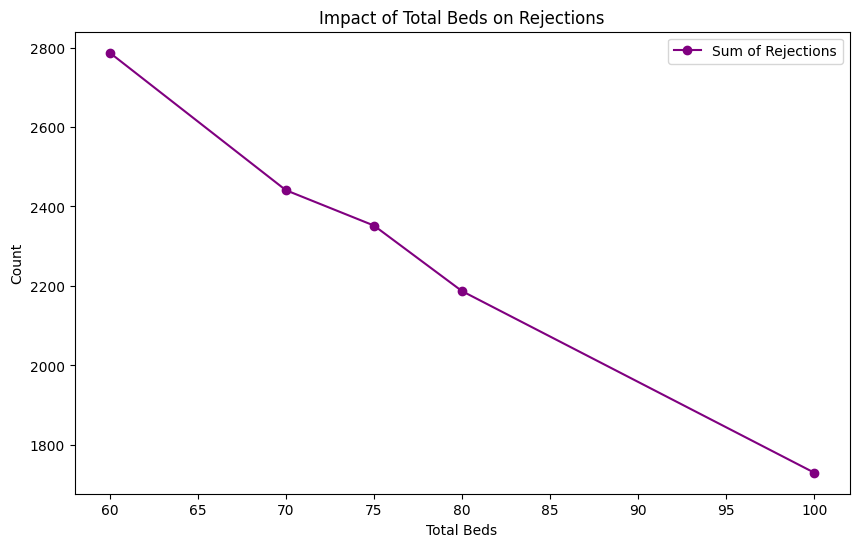

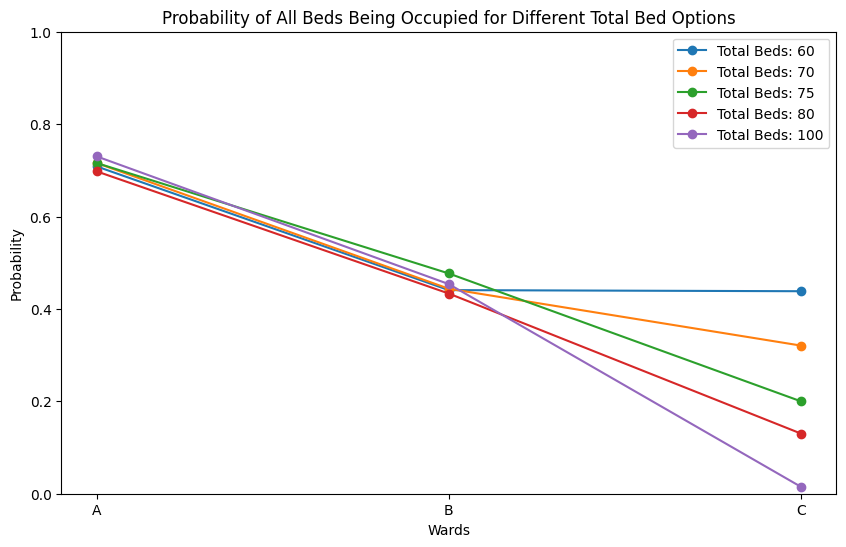

In [81]:
# Visualise the distribution of beds for sum of rejections and ICU overflows for different total bed options

plt.figure(figsize=(10, 6))
plt.plot(total_beds_options, [simulate_patient_flow(bed_distribution, simulation_days=365, Ward_A_LOS=Ward_A_LOS, Ward_B_LOS=Ward_B_LOS, Ward_C_LOS=Ward_C_LOS, total_beds=beds)["rejected"]["Sum"] for beds in total_beds_options], marker='o', label='Sum of Rejections', color='purple')
plt.title('Impact of Total Beds on Rejections')
plt.xlabel('Total Beds')
plt.ylabel('Count')
plt.legend()
plt.show()

# Visualise probability of all beds being occupied for each ward for different total bed options
plt.figure(figsize=(10, 6))
for beds in total_beds_options:
    results = simulate_patient_flow(bed_distribution, simulation_days=365, Ward_A_LOS=Ward_A_LOS, 
    Ward_B_LOS=Ward_B_LOS, Ward_C_LOS=Ward_C_LOS, total_beds=beds)
    
    probabilities = [results['blocking_probability'][ward] for ward in wards]
    plt.plot(wards, probabilities, marker='o', label=f'Total Beds: {beds}')

plt.title('Probability of All Beds Being Occupied for Different Total Bed Options')
plt.xlabel('Wards')
plt.ylabel('Probability')
plt.ylim(0, 1)
plt.legend()
plt.show()